# Meeting Extraction Evaluation: Base vs Fine-tuned Model

**Best Checkpoint:** checkpoint-31500 (validation loss: 0.225720)

This notebook evaluates  fine-tuned Qwen 2.5 14B model against the base model.

## Setup

In [ ]:
!pip install modelscope

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 150.7 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install dependencies
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q pandas tqdm

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 165.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.6/401.6 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 131.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 22.5 MB/s eta 0:00:00


In [ ]:
import os
os.environ['UNSLOTH_USE_MODELSCOPE'] = '1'
os.environ['UNSLOTH_SKIP_STATISTICS'] = '1'
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '600'

In [ ]:
import json
import torch
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
from unsloth import FastLanguageModel
from typing import Dict, List, Tuple

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


## Configuration

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-14B-Instruct"
HF_TOKEN = "your_hf_TOKEN"

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"
CHECKPOINT_DIR = "/content/drive/MyDrive/Colab Notebooks"

CHECKPOINT_NAME = "checkpoint-3150"

TEST_FILE = f"{DATA_DIR}/test.jsonl"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/{CHECKPOINT_NAME}"

print(f"Test file: {TEST_FILE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Test file: /content/drive/MyDrive/Colab Notebooks/test.jsonl
Checkpoint: /content/drive/MyDrive/Colab Notebooks/checkpoint-3150


## Load Test Data

In [ ]:
# Load test data
test_data = []
with open(TEST_FILE, 'r') as f:
    for line in f:
        test_data.append(json.loads(line))

print(f"✓ Loaded {len(test_data)} test examples")

# Optional: Use subset for quick testing (comment out for full evaluation)
# test_data = test_data[:20]
# print(f"  Using first {len(test_data)} examples for quick testing")

✓ Loaded 709 test examples


## Load Models

In [ ]:
print("="*80)
print("LOADING CLEAN BASE MODEL")
print("="*80)

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
    token=HF_TOKEN,
)

print("✓ Clean base model loaded")

LOADING CLEAN BASE MODEL


2026-03-18 17:48:12,986 - modelscope - INFO - Got 14 files, start to download ...


Processing 14 items:   0%|          | 0.00/14.0 [00:00<?, ?it/s]

2026-03-18 20:34:00,186 - modelscope - INFO - Download model 'unsloth/qwen2.5-14b-instruct-unsloth-bnb-4bit' successfully.
2026-03-18 20:34:00,187 - modelscope - INFO - Creating symbolic link [/root/.cache/modelscope/hub/models/unsloth/qwen2.5-14b-instruct-unsloth-bnb-4bit].


==((====))==  Unsloth 2026.3.7: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

/root/.cache/modelscope/hub/models/unsloth/qwen2___5-14b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✓ Clean base model loaded


In [ ]:
print("="*80)
print("LOADING SEPARATE MODEL FOR FINE-TUNED")
print("="*80)

ft_model, ft_tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
    token=HF_TOKEN,
)

print("✓ Separate fine-tuning base loaded")

LOADING SEPARATE MODEL FOR FINE-TUNED


2026-03-18 20:35:21,197 - modelscope - INFO - Target directory already exists, skipping creation.


==((====))==  Unsloth 2026.3.7: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

/root/.cache/modelscope/hub/models/unsloth/qwen2___5-14b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✓ Separate fine-tuning base loaded


In [ ]:
from peft import PeftModel

print("="*80)
print("ATTACHING LORA TO FT MODEL")
print("="*80)

ft_model = PeftModel.from_pretrained(
    ft_model,
    CHECKPOINT_PATH,
)

print("✓ LoRA attached to fine-tuned model")

ATTACHING LORA TO FT MODEL
✓ LoRA attached to fine-tuned model


In [ ]:
print(ft_model.base_model.model is base_model)

False


In [ ]:
# CELL 1: Helper Functions (UPDATED + SAFE)
# ============================================================================

import json
import re
import numpy as np
import pandas as pd
import torch
from typing import Dict, List, Tuple


def parse_json(text: str) -> Tuple[Dict, bool]:
    """Extract and parse JSON from model output"""
    text = text.strip()

    # Remove markdown code blocks
    if "```json" in text:
        text = text.split("```json")[1].split("```")[0].strip()
    elif "```" in text:
        text = text.split("```")[1].split("```")[0].strip()

    # Extract JSON object
    json_match = re.search(r'\{.*\}', text, re.DOTALL)
    if json_match:
        text = json_match.group(0)

    try:
        parsed = json.loads(text)
        return parsed, True
    except:
        return {}, False


def normalize_attendees(attendees_list: List[str]) -> List[str]:
    """Normalize email addresses for comparison"""
    return sorted([email.lower().strip() for email in attendees_list if email])


def calculate_array_f1(pred_list: List, true_list: List) -> Dict:
    """Calculate precision, recall, F1 for arrays (e.g., attendees)"""
    pred_set = set(normalize_attendees(pred_list)) if pred_list else set()
    true_set = set(normalize_attendees(true_list)) if true_list else set()

    if len(true_set) == 0:
        return {
            "precision": 1.0 if len(pred_set) == 0 else 0.0,
            "recall": 1.0,
            "f1": 1.0 if len(pred_set) == 0 else 0.0
        }

    if len(pred_set) == 0:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    tp = len(pred_set & true_set)
    precision = tp / len(pred_set)
    recall = tp / len(true_set)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {"precision": precision, "recall": recall, "f1": f1}


def normalize_time_confidence(value):
    """Normalize time_confidence values for comparison"""
    if value is None or value == "none":
        return "none"
    return value


def run_inference(model, tokenizer, email: str) -> str:
    """Run model inference on an email"""

    system_prompt = """You are a specialized meeting information extraction system.

TASK: Analyze emails and extract structured meeting details with high precision.

OUTPUT FORMAT (JSON only, no explanations):
{
  "is_meeting": boolean,
  "title": string or null,
  "attendees": array of email addresses,
  "start_time": ISO 8601 string or null,
  "end_time": ISO 8601 string or null,
  "location": string or null,
  "time_confidence": "high" | "medium" | "low" | "none"
}

CRITICAL: ALWAYS return valid JSON. NEVER add explanations."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": email}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=256,
            do_sample=False,
            temperature=0.0,
            use_cache=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Only decode generated tokens (IMPORTANT FIX)
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return response.strip()

In [ ]:
test_examples = [0, 3, 4]

for idx in test_examples:
    print("\n" + "="*80)
    print(f"EXAMPLE {idx}")
    print("="*80)

    email = [m["content"] for m in test_data[idx]["messages"] if m["role"] == "user"][0]

    base_out = run_inference(base_model, base_tokenizer, email)
    ft_out = run_inference(ft_model, ft_tokenizer, email)

    print("BASE OUTPUT:")
    print(base_out[:1000])

    print("\nFT OUTPUT:")
    print(ft_out[:1000])

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



EXAMPLE 0


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

BASE OUTPUT:
{
  "is_meeting": false,
  "title": null,
  "attendees": [],
  "start_time": null,
  "end_time": null,
  "location": null,
  "time_confidence": "none"
}

FT OUTPUT:
{
  "is_meeting": false,
  "title": null,
  "attendees": [],
  "start_time": null,
  "end_time": null,
  "location": null,
  "time_confidence": null
}

EXAMPLE 3


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE OUTPUT:
{
  "is_meeting": true,
  "title": "launch of bauer college energy committee",
  "attendees": [],
  "start_time": "2001-11-14T17:00:00Z",
  "end_time": "2001-11-14T19:00:00Z",
  "location": "Bauer College of Business - Melcher Hall, AIM Center Board Room",
  "time_confidence": "high"
}

FT OUTPUT:
{
  "is_meeting": true,
  "title": "launch of bauer college energy committee",
  "attendees": [],
  "start_time": "2001-11-14T23:00:00Z",
  "end_time": "2001-11-15T01:00:00Z",
  "location": "Bauer College of Business - Melcher Hall in the AIM Center Board Room",
  "time_confidence": "medium"
}

EXAMPLE 4


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE OUTPUT:
{
  "is_meeting": true,
  "title": "esa legal management meeting",
  "attendees": [],
  "start_time": "2023-06-14T15:00:00-03:00",
  "end_time": null,
  "location": null,
  "time_confidence": "high"
}

FT OUTPUT:
{
  "is_meeting": true,
  "title": "esa legal management meeting",
  "attendees": [],
  "start_time": "2000-06-14T19:00:00Z",
  "end_time": null,
  "location": null,
  "time_confidence": "medium"
}


In [ ]:
# Run Evaluation Function
# ============================================================================
def evaluate_model(model, tokenizer, test_data, model_name):
    """Evaluate a model on test data"""
    results = []

    for example in tqdm(test_data, desc=f"Evaluating {model_name}"):
        # Extract email and ground truth from messages
        email = [m['content'] for m in example['messages'] if m['role'] == 'user'][0]
        gt_text = [m['content'] for m in example['messages'] if m['role'] == 'assistant'][0]
        ground_truth, _ = parse_json(gt_text)

        # Run inference
        pred_text = run_inference(model, tokenizer, email)
        prediction, pred_valid = parse_json(pred_text)

        results.append({
            'ground_truth': ground_truth,
            'prediction': prediction,
            'pred_valid': pred_valid,
            'pred_text': pred_text,  # ← ADD THIS LINE!!
            'email': email[:200]  # Store snippet for debugging
        })

    return results

In [ ]:
sample_base_results = evaluate_model(base_model, base_tokenizer, test_data[:10], "Base")
sample_ft_results = evaluate_model(ft_model, ft_tokenizer, test_data[:10], "Fine-tuned")

Evaluating Fine-tuned: 100%|██████████| 10/10 [03:16<00:00, 19.65s/it]


In [ ]:
# Calculate Comprehensive Metrics
# ============================================================================
def calculate_comprehensive_metrics(results):
    """Calculate detailed metrics separating meeting vs non-meeting emails"""
    n = len(results)

    # Overall counters
    json_valid = 0
    full_exact_match = 0

    # Meeting detection (binary classification)
    true_positives = 0   # Correctly identified meetings
    false_positives = 0  # Non-meetings labeled as meetings
    true_negatives = 0   # Correctly identified non-meetings
    false_negatives = 0  # Meetings labeled as non-meetings

    # Conditional metrics (only for actual meetings)
    meeting_title_correct = 0
    meeting_location_correct = 0
    meeting_start_time_correct = 0
    meeting_end_time_correct = 0
    meeting_time_confidence_correct = 0
    meeting_attendees_metrics = []

    # Conditional metrics (only for actual non-meetings)
    non_meeting_all_null_correct = 0

    # Track counts
    actual_meetings = 0
    actual_non_meetings = 0

    for r in results:
        pred = r['prediction']
        gt = r['ground_truth']

        # JSON validity
        if r['pred_valid']:
            json_valid += 1
        else:
            continue  # Skip invalid predictions for other metrics

        # Determine actual label
        is_actual_meeting = gt.get('is_meeting', False)
        is_predicted_meeting = pred.get('is_meeting', False)

        if is_actual_meeting:
            actual_meetings += 1
        else:
            actual_non_meetings += 1

        # Meeting detection metrics (confusion matrix)
        if is_actual_meeting and is_predicted_meeting:
            true_positives += 1
        elif not is_actual_meeting and is_predicted_meeting:
            false_positives += 1
        elif not is_actual_meeting and not is_predicted_meeting:
            true_negatives += 1
        elif is_actual_meeting and not is_predicted_meeting:
            false_negatives += 1

        # Normalize time_confidence for comparison
        pred_time_conf = normalize_time_confidence(pred.get('time_confidence'))
        gt_time_conf = normalize_time_confidence(gt.get('time_confidence'))

        # Full exact match (all fields)
        attendees_match = set(normalize_attendees(pred.get('attendees', []))) == set(normalize_attendees(gt.get('attendees', [])))

        if all([
            pred.get('is_meeting') == gt.get('is_meeting'),
            pred.get('title') == gt.get('title'),
            attendees_match,
            pred.get('start_time') == gt.get('start_time'),
            pred.get('end_time') == gt.get('end_time'),
            pred.get('location') == gt.get('location'),
            pred_time_conf == gt_time_conf
        ]):
            full_exact_match += 1

        # Conditional metrics for ACTUAL MEETINGS
        if is_actual_meeting:
            if pred.get('title') == gt.get('title'):
                meeting_title_correct += 1

            if pred.get('location') == gt.get('location'):
                meeting_location_correct += 1

            if pred.get('start_time') == gt.get('start_time'):
                meeting_start_time_correct += 1

            if pred.get('end_time') == gt.get('end_time'):
                meeting_end_time_correct += 1

            if pred_time_conf == gt_time_conf:
                meeting_time_confidence_correct += 1

            att_metrics = calculate_array_f1(
                pred.get('attendees', []),
                gt.get('attendees', [])
            )
            meeting_attendees_metrics.append(att_metrics)

        # Conditional metrics for ACTUAL NON-MEETINGS
        if not is_actual_meeting:
            # Check if all fields are correctly null/empty
            pred_title_null = pred.get('title') is None or pred.get('title') == ''
            pred_attendees_empty = pred.get('attendees', []) == []
            pred_start_null = pred.get('start_time') is None
            pred_end_null = pred.get('end_time') is None
            pred_location_null = pred.get('location') is None or pred.get('location') == ''
            pred_conf_none = normalize_time_confidence(pred.get('time_confidence')) == 'none'

            all_null = all([
                pred_title_null,
                pred_attendees_empty,
                pred_start_null,
                pred_end_null,
                pred_location_null,
                pred_conf_none
            ])

            if all_null:
                non_meeting_all_null_correct += 1

    # Calculate meeting detection metrics
    meeting_precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    meeting_recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    meeting_f1 = 2 * meeting_precision * meeting_recall / (meeting_precision + meeting_recall) if (meeting_precision + meeting_recall) > 0 else 0
    meeting_accuracy = (true_positives + true_negatives) / n

    # Calculate conditional metrics for meetings
    meeting_metrics = {}
    if actual_meetings > 0:
        meeting_metrics = {
            "title_accuracy": meeting_title_correct / actual_meetings,
            "location_accuracy": meeting_location_correct / actual_meetings,
            "start_time_accuracy": meeting_start_time_correct / actual_meetings,
            "end_time_accuracy": meeting_end_time_correct / actual_meetings,
            "time_confidence_accuracy": meeting_time_confidence_correct / actual_meetings,
            "attendees_precision": np.mean([m['precision'] for m in meeting_attendees_metrics]) if meeting_attendees_metrics else 0,
            "attendees_recall": np.mean([m['recall'] for m in meeting_attendees_metrics]) if meeting_attendees_metrics else 0,
            "attendees_f1": np.mean([m['f1'] for m in meeting_attendees_metrics]) if meeting_attendees_metrics else 0,
        }

    # Calculate conditional metrics for non-meetings
    non_meeting_metrics = {}
    if actual_non_meetings > 0:
        non_meeting_metrics = {
            "all_fields_null_accuracy": non_meeting_all_null_correct / actual_non_meetings,
        }

    return {
        "overall": {
            "json_validity": json_valid / n,
            "full_exact_match": full_exact_match / n,
        },
        "meeting_detection": {
            "accuracy": meeting_accuracy,
            "precision": meeting_precision,
            "recall": meeting_recall,
            "f1": meeting_f1,
            "true_positives": true_positives,
            "false_positives": false_positives,
            "true_negatives": true_negatives,
            "false_negatives": false_negatives,
        },
        "meeting_extraction": meeting_metrics,
        "non_meeting_verification": non_meeting_metrics,
        "counts": {
            "total": n,
            "actual_meetings": actual_meetings,
            "actual_non_meetings": actual_non_meetings,
        }
    }

In [ ]:
sample_base_metrics = calculate_comprehensive_metrics(sample_base_results)
sample_ft_metrics = calculate_comprehensive_metrics(sample_ft_results)

print("Base metrics:")
print(sample_base_metrics)

print("\nFine-tuned metrics:")
print(sample_ft_metrics)

Base metrics:
{'overall': {'json_validity': 1.0, 'full_exact_match': 0.3}, 'meeting_detection': {'accuracy': 0.7, 'precision': 0.75, 'recall': 0.6, 'f1': 0.6666666666666665, 'true_positives': 3, 'false_positives': 1, 'true_negatives': 4, 'false_negatives': 2}, 'meeting_extraction': {'title_accuracy': 0.4, 'location_accuracy': 0.6, 'start_time_accuracy': 0.4, 'end_time_accuracy': 0.6, 'time_confidence_accuracy': 0.2, 'attendees_precision': np.float64(0.6), 'attendees_recall': np.float64(0.6), 'attendees_f1': np.float64(0.6)}, 'non_meeting_verification': {'all_fields_null_accuracy': 0.6}, 'counts': {'total': 10, 'actual_meetings': 5, 'actual_non_meetings': 5}}

Fine-tuned metrics:
{'overall': {'json_validity': 0.9, 'full_exact_match': 0.4}, 'meeting_detection': {'accuracy': 0.7, 'precision': 0.75, 'recall': 0.75, 'f1': 0.75, 'true_positives': 3, 'false_positives': 1, 'true_negatives': 4, 'false_negatives': 1}, 'meeting_extraction': {'title_accuracy': 0.75, 'location_accuracy': 0.75, 'sta

###Full Run

In [ ]:
base_results = evaluate_model(base_model, base_tokenizer, test_data, "Base")
ft_results = evaluate_model(ft_model, ft_tokenizer, test_data, "Fine-tuned")

Evaluating Fine-tuned: 100%|██████████| 709/709 [2:51:45<00:00, 14.53s/it]


In [ ]:
base_metrics = calculate_comprehensive_metrics(base_results)
ft_metrics = calculate_comprehensive_metrics(ft_results)

print("Base metrics:")
print(base_metrics)

print("\nFine-tuned metrics:")
print(ft_metrics)

Base metrics:
{'overall': {'json_validity': 0.997179125528914, 'full_exact_match': 0.6290550070521862}, 'meeting_detection': {'accuracy': 0.9026798307475318, 'precision': 0.8190045248868778, 'recall': 0.8701923076923077, 'f1': 0.8438228438228438, 'true_positives': 181, 'false_positives': 40, 'true_negatives': 459, 'false_negatives': 27}, 'meeting_extraction': {'title_accuracy': 0.2403846153846154, 'location_accuracy': 0.7548076923076923, 'start_time_accuracy': 0.27884615384615385, 'end_time_accuracy': 0.6009615384615384, 'time_confidence_accuracy': 0.36538461538461536, 'attendees_precision': np.float64(0.624496336996337), 'attendees_recall': np.float64(0.77817495004995), 'attendees_f1': np.float64(0.6236643290919607)}, 'non_meeting_verification': {'all_fields_null_accuracy': 0.8877755511022044}, 'counts': {'total': 709, 'actual_meetings': 208, 'actual_non_meetings': 499}}

Fine-tuned metrics:
{'overall': {'json_validity': 0.9929478138222849, 'full_exact_match': 0.7447108603667136}, 'me

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json

with open("/content/drive/MyDrive/base_results.json", "w") as f:
    json.dump(base_results, f, default=str)

with open("/content/drive/MyDrive/ft_results.json", "w") as f:
    json.dump(ft_results, f, default=str)

with open("/content/drive/MyDrive/base_metrics.json", "w") as f:
    json.dump(base_metrics, f, default=str)

with open("/content/drive/MyDrive/ft_metrics.json", "w") as f:
    json.dump(ft_metrics, f, default=str)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json

# Save results (needed for G-Eval later)
with open("/content/drive/MyDrive/base_results.json", "w") as f:
    json.dump(base_results, f, default=str)

with open("/content/drive/MyDrive/ft_results.json", "w") as f:
    json.dump(ft_results, f, default=str)

# Save metrics (needed for plots + report)
with open("/content/drive/MyDrive/base_metrics.json", "w") as f:
    json.dump(base_metrics, f, default=str)

with open("/content/drive/MyDrive/ft_metrics.json", "w") as f:
    json.dump(ft_metrics, f, default=str)

###CHART 1: Detection + Overall

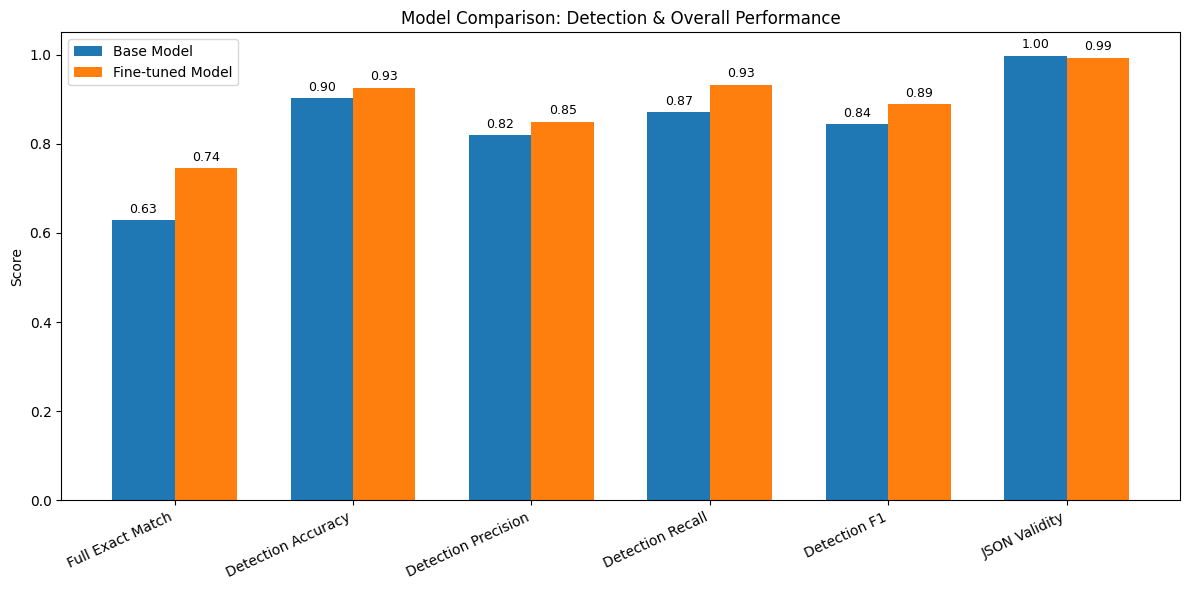

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = [
    "Full Exact Match",
    "Detection Accuracy",
    "Detection Precision",
    "Detection Recall",
    "Detection F1",
    "JSON Validity"
]

base_vals = [
    float(base_metrics["overall"]["full_exact_match"]),
    float(base_metrics["meeting_detection"]["accuracy"]),
    float(base_metrics["meeting_detection"]["precision"]),
    float(base_metrics["meeting_detection"]["recall"]),
    float(base_metrics["meeting_detection"]["f1"]),
    float(base_metrics["overall"]["json_validity"]),
]

ft_vals = [
    float(ft_metrics["overall"]["full_exact_match"]),
    float(ft_metrics["meeting_detection"]["accuracy"]),
    float(ft_metrics["meeting_detection"]["precision"]),
    float(ft_metrics["meeting_detection"]["recall"]),
    float(ft_metrics["meeting_detection"]["f1"]),
    float(ft_metrics["overall"]["json_validity"]),
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, base_vals, width, label="Base Model")
bars2 = plt.bar(x + width/2, ft_vals, width, label="Fine-tuned Model")

plt.xticks(x, labels, rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Comparison: Detection & Overall Performance")
plt.legend()

# Add data labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

###CHART 2: Extraction Quality

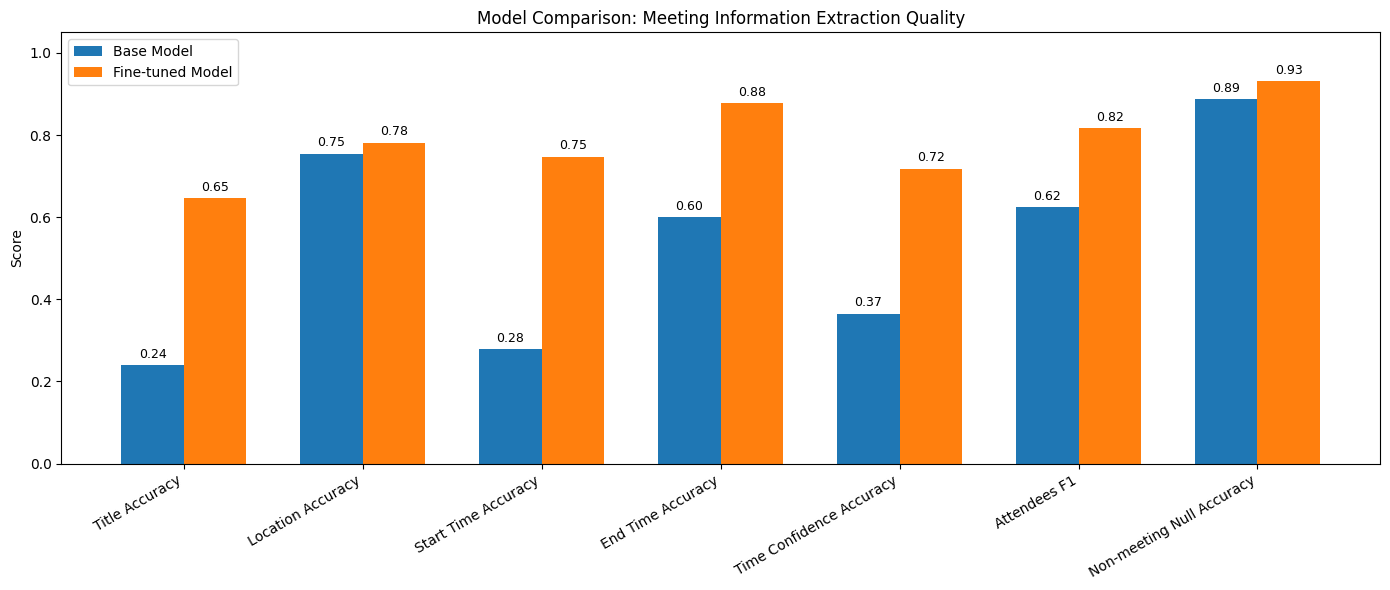

In [ ]:
labels = [
    "Title Accuracy",
    "Location Accuracy",
    "Start Time Accuracy",
    "End Time Accuracy",
    "Time Confidence Accuracy",
    "Attendees F1",
    "Non-meeting Null Accuracy"
]

base_vals = [
    float(base_metrics["meeting_extraction"]["title_accuracy"]),
    float(base_metrics["meeting_extraction"]["location_accuracy"]),
    float(base_metrics["meeting_extraction"]["start_time_accuracy"]),
    float(base_metrics["meeting_extraction"]["end_time_accuracy"]),
    float(base_metrics["meeting_extraction"]["time_confidence_accuracy"]),
    float(base_metrics["meeting_extraction"]["attendees_f1"]),
    float(base_metrics["non_meeting_verification"]["all_fields_null_accuracy"]),
]

ft_vals = [
    float(ft_metrics["meeting_extraction"]["title_accuracy"]),
    float(ft_metrics["meeting_extraction"]["location_accuracy"]),
    float(ft_metrics["meeting_extraction"]["start_time_accuracy"]),
    float(ft_metrics["meeting_extraction"]["end_time_accuracy"]),
    float(ft_metrics["meeting_extraction"]["time_confidence_accuracy"]),
    float(ft_metrics["meeting_extraction"]["attendees_f1"]),
    float(ft_metrics["non_meeting_verification"]["all_fields_null_accuracy"]),
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(14, 6))
bars1 = plt.bar(x - width/2, base_vals, width, label="Base Model")
bars2 = plt.bar(x + width/2, ft_vals, width, label="Fine-tuned Model")

plt.xticks(x, labels, rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Comparison: Meeting Information Extraction Quality")
plt.legend()

# Add data labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [ ]:
print(type(base_results), len(base_results))
print(type(ft_results), len(ft_results))

<class 'list'> 709
<class 'list'> 709


###G-Eval

###Helper functions for adapted G-Eval

In [ ]:
import re
import math
import numpy as np
from datetime import datetime

def normalize_str(x):
    if x is None:
        return None
    return str(x).strip().lower()

def normalize_attendees_list(attendees):
    if not attendees:
        return []
    return sorted([str(a).strip().lower() for a in attendees if str(a).strip()])

def safe_get(d, key, default=None):
    return d.get(key, default) if isinstance(d, dict) else default

def is_valid_iso_like(ts):
    if ts is None:
        return True
    if not isinstance(ts, str):
        return False
    # Loose ISO-8601 style check
    pattern = r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(Z|[+-]\d{2}:\d{2})?$"
    return re.match(pattern, ts) is not None

def parse_dt(ts):
    if ts is None or not isinstance(ts, str):
        return None
    try:
        if ts.endswith("Z"):
            ts = ts.replace("Z", "+00:00")
        return datetime.fromisoformat(ts)
    except:
        return None

def schema_validity_score(pred):
    required_keys = {
        "is_meeting", "title", "attendees",
        "start_time", "end_time", "location", "time_confidence"
    }
    if not isinstance(pred, dict):
        return 0.0

    score = 0.0

    # Has all keys
    keys = set(pred.keys())
    score += 1.0 if required_keys.issubset(keys) else 0.0

    # Type checks
    score += 1.0 if isinstance(pred.get("is_meeting"), bool) else 0.0
    score += 1.0 if (pred.get("title") is None or isinstance(pred.get("title"), str)) else 0.0
    score += 1.0 if isinstance(pred.get("attendees"), list) else 0.0
    score += 1.0 if (pred.get("start_time") is None or isinstance(pred.get("start_time"), str)) else 0.0
    score += 1.0 if (pred.get("end_time") is None or isinstance(pred.get("end_time"), str)) else 0.0
    score += 1.0 if (pred.get("location") is None or isinstance(pred.get("location"), str)) else 0.0
    score += 1.0 if (pred.get("time_confidence") in [None, "none", "low", "medium", "high"]) else 0.0

    # Time format sanity
    score += 1.0 if is_valid_iso_like(pred.get("start_time")) else 0.0
    score += 1.0 if is_valid_iso_like(pred.get("end_time")) else 0.0

    return score / 10.0

def intent_correctness_score(pred, gt):
    return 1.0 if safe_get(pred, "is_meeting") == safe_get(gt, "is_meeting") else 0.0

def field_accuracy_score(pred, gt):
    fields = ["title", "start_time", "end_time", "location", "time_confidence"]
    field_scores = []

    for field in fields:
        p = normalize_str(safe_get(pred, field))
        g = normalize_str(safe_get(gt, field))
        field_scores.append(1.0 if p == g else 0.0)

    p_att = set(normalize_attendees_list(safe_get(pred, "attendees", [])))
    g_att = set(normalize_attendees_list(safe_get(gt, "attendees", [])))

    if len(g_att) == 0 and len(p_att) == 0:
        attendees_score = 1.0
    elif len(g_att) == 0 and len(p_att) > 0:
        attendees_score = 0.0
    elif len(p_att) == 0:
        attendees_score = 0.0
    else:
        inter = len(p_att & g_att)
        prec = inter / len(p_att) if len(p_att) > 0 else 0.0
        rec = inter / len(g_att) if len(g_att) > 0 else 0.0
        attendees_score = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    field_scores.append(attendees_score)
    return float(np.mean(field_scores))

def completeness_score(pred, gt):
    relevant_fields = ["title", "attendees", "start_time", "end_time", "location", "time_confidence"]

    gt_present = 0
    pred_correctly_present = 0

    for f in relevant_fields:
        g = safe_get(gt, f)
        p = safe_get(pred, f)

        gt_has_value = (
            (isinstance(g, list) and len(g) > 0) or
            (g is not None and g != "" and g != "none")
        )

        if gt_has_value:
            gt_present += 1

            if f == "attendees":
                p_set = set(normalize_attendees_list(p or []))
                g_set = set(normalize_attendees_list(g or []))
                if len(g_set) > 0 and len(p_set & g_set) > 0:
                    pred_correctly_present += 1
            else:
                if normalize_str(p) == normalize_str(g):
                    pred_correctly_present += 1

    if gt_present == 0:
        return 1.0
    return pred_correctly_present / gt_present

def consistency_score(pred):
    if not isinstance(pred, dict):
        return 0.0

    score_parts = []

    is_meeting = safe_get(pred, "is_meeting")

    # Non-meeting consistency
    if is_meeting is False:
        null_like = 0
        checks = [
            safe_get(pred, "title") in [None, ""],
            safe_get(pred, "attendees", []) == [],
            safe_get(pred, "start_time") is None,
            safe_get(pred, "end_time") is None,
            safe_get(pred, "location") in [None, ""],
            safe_get(pred, "time_confidence") in [None, "none"]
        ]
        null_like = sum(checks) / len(checks)
        score_parts.append(null_like)

    # Time consistency
    st = parse_dt(safe_get(pred, "start_time"))
    et = parse_dt(safe_get(pred, "end_time"))
    if st is None or et is None:
        score_parts.append(1.0)
    else:
        score_parts.append(1.0 if et >= st else 0.0)

    # Meeting-time consistency
    if is_meeting is True:
        tc = safe_get(pred, "time_confidence")
        has_any_time = (safe_get(pred, "start_time") is not None) or (safe_get(pred, "end_time") is not None)
        score_parts.append(1.0 if (has_any_time or tc in ["none", None]) else 0.0)

    return float(np.mean(score_parts)) if score_parts else 0.0

def non_meeting_handling_score(pred, gt):
    if safe_get(gt, "is_meeting") is not False:
        return None

    checks = [
        safe_get(pred, "is_meeting") is False,
        safe_get(pred, "title") in [None, ""],
        safe_get(pred, "attendees", []) == [],
        safe_get(pred, "start_time") is None,
        safe_get(pred, "end_time") is None,
        safe_get(pred, "location") in [None, ""],
        safe_get(pred, "time_confidence") in [None, "none"],
    ]
    return sum(checks) / len(checks)

def overall_extraction_quality(pred, gt):
    intent = intent_correctness_score(pred, gt)
    field_acc = field_accuracy_score(pred, gt)
    complete = completeness_score(pred, gt)
    consist = consistency_score(pred)
    schema = schema_validity_score(pred)

    nmh = non_meeting_handling_score(pred, gt)
    if nmh is None:
        overall = np.mean([intent, field_acc, complete, consist, schema])
    else:
        overall = np.mean([intent, field_acc, complete, consist, schema, nmh])

    return {
        "intent_correctness": round(intent, 4),
        "field_accuracy": round(field_acc, 4),
        "completeness": round(complete, 4),
        "consistency": round(consist, 4),
        "schema_validity": round(schema, 4),
        "non_meeting_handling": None if nmh is None else round(nmh, 4),
        "overall_quality": round(float(overall), 4),
    }

###Run adapted G-Eval on a subset

In [ ]:
N = 500

base_subset = base_results[:N]
ft_subset = ft_results[:N]

geval_rows = []

for i, (b, f) in enumerate(zip(base_subset, ft_subset)):
    gt = b["ground_truth"]  # same underlying example
    email = b["email"]

    base_eval = overall_extraction_quality(b["prediction"], gt)
    ft_eval = overall_extraction_quality(f["prediction"], gt)

    if ft_eval["overall_quality"] > base_eval["overall_quality"]:
        winner = "fine-tuned"
    elif ft_eval["overall_quality"] < base_eval["overall_quality"]:
        winner = "base"
    else:
        winner = "tie"

    geval_rows.append({
        "index": i,
        "email": email,
        "base": base_eval,
        "fine_tuned": ft_eval,
        "winner": winner
    })

print(f"Computed adapted G-Eval on {len(geval_rows)} examples")

Computed adapted G-Eval on 500 examples


###Aggregate G-Eval results

In [ ]:
import pandas as pd
import numpy as np

metrics = [
    "intent_correctness",
    "field_accuracy",
    "completeness",
    "consistency",
    "overall_quality"
]

# non_meeting_handling is optional because it's None for actual meetings
base_summary = {}
ft_summary = {}

for m in metrics:
    base_summary[m] = np.mean([row["base"][m] for row in geval_rows])
    ft_summary[m] = np.mean([row["fine_tuned"][m] for row in geval_rows])

# Handle non_meeting_handling separately
base_nmh = [row["base"]["non_meeting_handling"] for row in geval_rows if row["base"]["non_meeting_handling"] is not None]
ft_nmh = [row["fine_tuned"]["non_meeting_handling"] for row in geval_rows if row["fine_tuned"]["non_meeting_handling"] is not None]

if len(base_nmh) > 0:
    base_summary["non_meeting_handling"] = np.mean(base_nmh)
    ft_summary["non_meeting_handling"] = np.mean(ft_nmh)

summary_df = pd.DataFrame({
    "Metric": list(base_summary.keys()),
    "Base": [round(base_summary[k], 4) for k in base_summary.keys()],
    "Fine-tuned": [round(ft_summary[k], 4) for k in ft_summary.keys()],
})

wins = pd.Series([row["winner"] for row in geval_rows]).value_counts()

print(summary_df)
print("\nWinner counts:")
print(wins)

                 Metric    Base  Fine-tuned
0    intent_correctness  0.9020      0.9220
1        field_accuracy  0.7064      0.9085
2          completeness  0.0575      0.1463
3           consistency  0.9832      0.9540
4       overall_quality  0.7548      0.8084
5  non_meeting_handling  0.9524      0.9631

Winner counts:
fine-tuned    442
base           32
tie            26
Name: count, dtype: int64


###Plot G-Eval Comparison

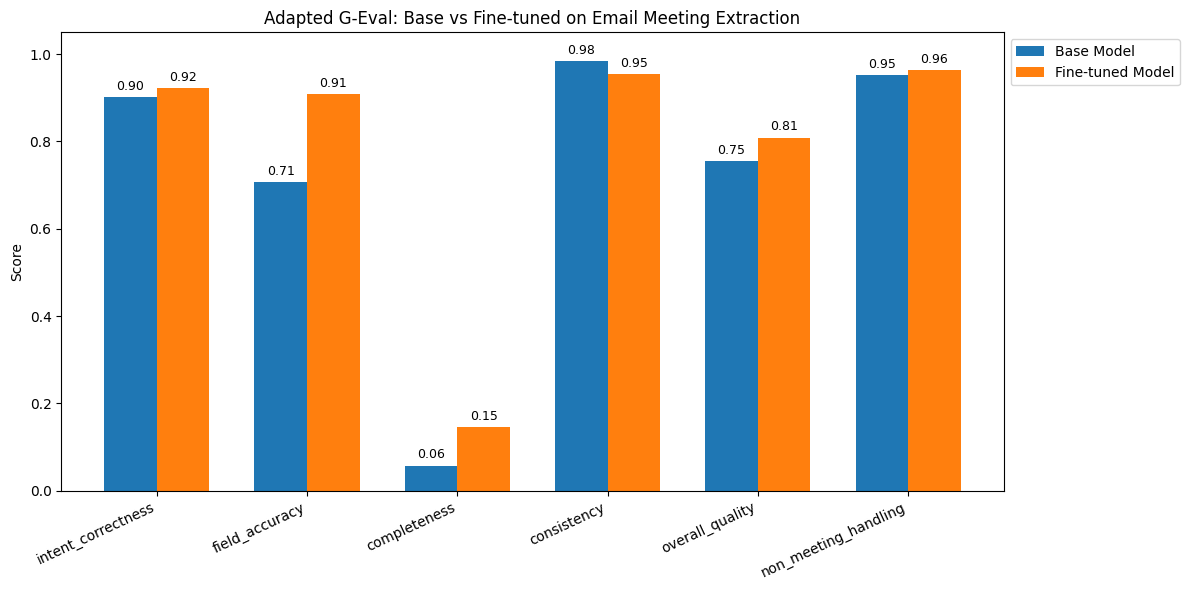

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = summary_df["Metric"].tolist()
base_vals = summary_df["Base"].tolist()
ft_vals = summary_df["Fine-tuned"].tolist()

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, base_vals, width, label="Base Model")
bars2 = plt.bar(x + width/2, ft_vals, width, label="Fine-tuned Model")

plt.xticks(x, labels, rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Adapted G-Eval: Base vs Fine-tuned on Email Meeting Extraction")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

###G-Eval with LLM

###Pick 100 aligned examples

In [ ]:
N = 100
base_subset = base_results[:N]
ft_subset = ft_results[:N]

assert len(base_subset) == len(ft_subset) == N

###Build judge prompt

In [ ]:
import json

def build_llm_geval_prompt(email, ground_truth, base_pred, ft_pred):
    return f"""
You are an expert evaluator for email meeting intent detection and structured meeting information extraction.

Evaluate two model outputs: a Base model output and a Fine-tuned model output.

EMAIL:
{email}

GROUND TRUTH:
{json.dumps(ground_truth, indent=2)}

BASE MODEL OUTPUT:
{json.dumps(base_pred, indent=2)}

FINE-TUNED MODEL OUTPUT:
{json.dumps(ft_pred, indent=2)}

Score BOTH models from 1 to 5 on the following dimensions:

1. intent_correctness
- Did the model correctly determine whether the email is a meeting or non-meeting?

2. field_accuracy
- How accurately were title, attendees, start_time, end_time, location, and time_confidence extracted?

3. completeness
- Did the model capture all relevant information present in the ground truth?

4. consistency
- Are the fields logically and internally consistent? For example, time ranges make sense, non-meeting emails do not contain hallucinated meeting fields, and outputs align with the email content.

5. non_meeting_handling
- If the email is a non-meeting, did the model correctly leave irrelevant fields empty/null? If the email is a meeting, score based on whether it avoids unnecessary nulls and uses fields appropriately.

6. overall_quality
- Overall usefulness and quality of the extraction.

Return ONLY valid JSON in this exact format:
{{
  "base": {{
    "intent_correctness": 1-5,
    "field_accuracy": 1-5,
    "completeness": 1-5,
    "consistency": 1-5,
    "non_meeting_handling": 1-5,
    "overall_quality": 1-5
  }},
  "fine_tuned": {{
    "intent_correctness": 1-5,
    "field_accuracy": 1-5,
    "completeness": 1-5,
    "consistency": 1-5,
    "non_meeting_handling": 1-5,
    "overall_quality": 1-5
  }},
  "winner": "base" or "fine_tuned" or "tie",
  "reason": "one short sentence"
}}
"""

###Configure judge client

In [ ]:
from openai import OpenAI
import os

os.environ["OPENAI_API_KEY"] = "your_API_key"

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
JUDGE_MODEL = "gpt-4o-mini"

###Safe Parser

In [ ]:
import re
import json

def parse_judge_json(text):
    text = text.strip()
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        text = match.group(0)
    return json.loads(text)

###Run judge-LLM G-Eval

In [ ]:
from tqdm import tqdm
import time

llm_geval_rows = []

for i, (b, f) in enumerate(tqdm(list(zip(base_subset, ft_subset)), desc="Running judge LLM G-Eval")):
    prompt = build_llm_geval_prompt(
        email=b["email"],
        ground_truth=b["ground_truth"],
        base_pred=b["prediction"],
        ft_pred=f["prediction"],
    )

    try:
        resp = client.chat.completions.create(
            model=JUDGE_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        raw = resp.choices[0].message.content
        parsed = parse_judge_json(raw)

        llm_geval_rows.append({
            "index": i,
            "email": b["email"],
            "ground_truth": b["ground_truth"],
            "base_prediction": b["prediction"],
            "ft_prediction": f["prediction"],
            "judge_result": parsed
        })

    except Exception as e:
        llm_geval_rows.append({
            "index": i,
            "email": b["email"],
            "ground_truth": b["ground_truth"],
            "base_prediction": b["prediction"],
            "ft_prediction": f["prediction"],
            "judge_result": None,
            "error": str(e)
        })

    time.sleep(0.2)

print("Done:", len(llm_geval_rows))

Running judge LLM G-Eval: 100%|██████████| 100/100 [06:49<00:00,  4.10s/it]

Done: 100


###Aggregate results

In [ ]:
import pandas as pd
import numpy as np

dimensions = [
    "field_accuracy",
    "completeness",
    "consistency",
    "non_meeting_handling",
    "overall_quality"
]

valid_rows = [r for r in llm_geval_rows if r.get("judge_result") is not None]

base_summary = {}
ft_summary = {}

for d in dimensions:
    base_summary[d] = np.mean([r["judge_result"]["base"][d] for r in valid_rows])
    ft_summary[d] = np.mean([r["judge_result"]["fine_tuned"][d] for r in valid_rows])

winner_counts = pd.Series([r["judge_result"]["winner"] for r in valid_rows]).value_counts()

summary_df = pd.DataFrame({
    "Metric": dimensions,
    "Base": [round(base_summary[d], 3) for d in dimensions],
    "Fine-tuned": [round(ft_summary[d], 3) for d in dimensions],
})

print(summary_df)
print("\nWinner counts:")
print(winner_counts)

                 Metric  Base  Fine-tuned
0        field_accuracy  4.20        4.42
1          completeness  4.13        4.34
2           consistency  4.32        4.36
3  non_meeting_handling  4.55        4.59
4       overall_quality  4.20        4.37

Winner counts:
tie           59
fine_tuned    27
base          14
Name: count, dtype: int64


###Plot judge-LLM G-Eval

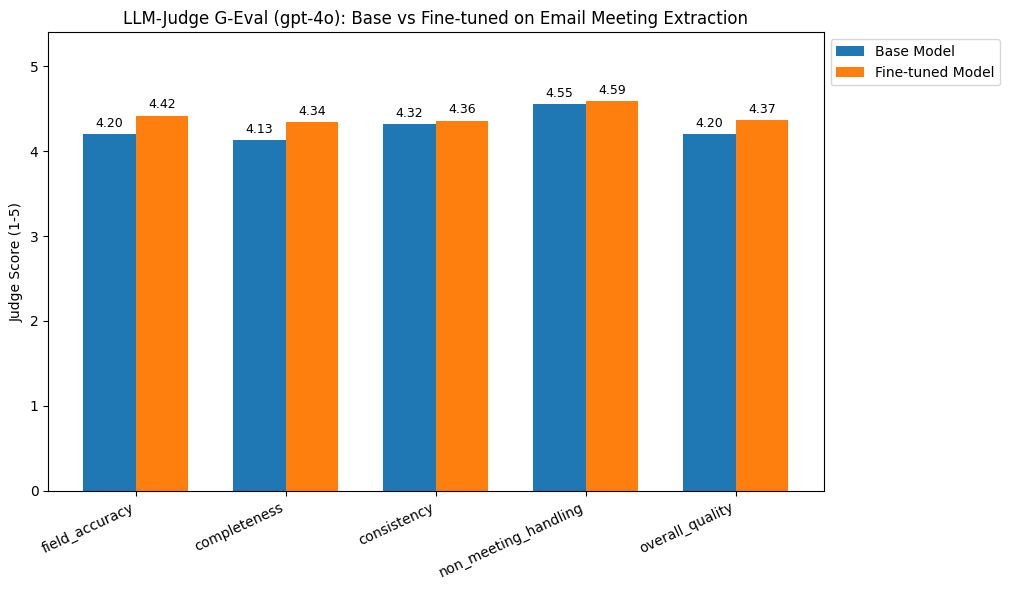

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = summary_df["Metric"].tolist()
base_vals = summary_df["Base"].tolist()
ft_vals = summary_df["Fine-tuned"].tolist()

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, base_vals, width, label="Base Model")
bars2 = plt.bar(x + width/2, ft_vals, width, label="Fine-tuned Model")

plt.xticks(x, labels, rotation=25, ha="right")
plt.ylim(0, 5.4)
plt.ylabel("Judge Score (1-5)")
plt.title("LLM-Judge G-Eval (gpt-4o): Base vs Fine-tuned on Email Meeting Extraction")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.05,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

###Save judge-LLM G-Eval results

In [ ]:
output = {
    "model": JUDGE_MODEL,
    "num_examples": len(valid_rows),
    "summary": summary_df.to_dict(orient="records"),
    "winner_counts": winner_counts.to_dict(),
    "rows": llm_geval_rows
}

with open("/content/drive/MyDrive/llm_geval_results.json", "w") as f:
    json.dump(output, f, indent=2, default=str)

print("Saved to /content/drive/MyDrive/llm_geval_results.json")

Saved to /content/drive/MyDrive/llm_geval_results.json
